# Detecção de Buracos com CNN Baseline

Notebook para treino e avaliacao de uma CNN baseline usando o dataset local `datasets/whole-detection/archive`.

**O que e uma CNN Baseline:** e uma rede convolucional simples usada como ponto de partida para classificacao de imagens, servindo como referencia inicial de desempenho antes de modelos mais complexos.

## 1. Objetivo

- Carregar o dataset local de imagens de pista normal e com buracos.
- Treinar uma CNN baseline para classificação binária.
- Avaliar com acurácia, precision, recall, f1-score e matriz de confusão.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Localiza a raiz do projeto para importar o pacote src de forma robusta no VS Code.
raiz_atual = Path.cwd().resolve()
projeto_raiz = next((p for p in [raiz_atual, *raiz_atual.parents] if (p / "src").exists()), raiz_atual)

if str(projeto_raiz) not in sys.path:
    sys.path.insert(0, str(projeto_raiz))

from src.deteccao_buracos import (
    MAPA_CLASSES,
    PROPORCAO_VALIDACAO_PADRAO,
    SEMENTE_PADRAO,
    TAMANHO_IMAGEM_PADRAO,
    avaliar_modelo,
    carregar_imagens_rotuladas,
    construir_cnn_baseline,
    obter_caminhos_dataset,
    separar_treino_validacao,
    treinar_modelo,
)

sns.set_theme(style="whitegrid")
print(f"Raiz do projeto: {projeto_raiz}")

Raiz do projeto: /Users/luccaromagnolli/Desktop/Civil-Engineering


## 2. Configuração

Definimos parametros de reproducibilidade, resolucao de imagem e hiperparametros de treino.

In [2]:
epocas = 10
batch_size = 32
forma_entrada = (TAMANHO_IMAGEM_PADRAO[0], TAMANHO_IMAGEM_PADRAO[1], 3)

caminhos = obter_caminhos_dataset()
print("Caminhos do dataset:")
for chave, valor in caminhos.items():
    print(f"- {chave}: {valor}")

print(f"\nMapa de classes: {MAPA_CLASSES}")
print(f"Tamanho de imagem: {TAMANHO_IMAGEM_PADRAO}")
print(f"Semente: {SEMENTE_PADRAO}")

Caminhos do dataset:
- base: /Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/whole-detection/archive
- normal: /Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/whole-detection/archive/normal
- potholes: /Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/whole-detection/archive/potholes

Mapa de classes: {'normal': 0, 'potholes': 1}
Tamanho de imagem: (128, 128)
Semente: 42


## 3. Carregamento e pré-processamento

As imagens são carregadas já normalizadas no intervalo `[0, 1]` e com rótulos binários.

In [3]:
X, y = carregar_imagens_rotuladas(caminhos["base"], TAMANHO_IMAGEM_PADRAO)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Faixa de valores em X: min={X.min():.4f}, max={X.max():.4f}")

classes_unicas, contagens = np.unique(y, return_counts=True)
distribuicao = dict(zip(classes_unicas, contagens))
print(f"Distribuicao de classes: {distribuicao}")

Shape de X: (681, 128, 128, 3)
Shape de y: (681,)
Faixa de valores em X: min=0.0000, max=1.0000
Distribuicao de classes: {np.int32(0): np.int64(352), np.int32(1): np.int64(329)}


## 4. EDA básica

Visualizamos distribuição de classes e amostras de cada categoria.

/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_6223/3655489498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_legiveis, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])


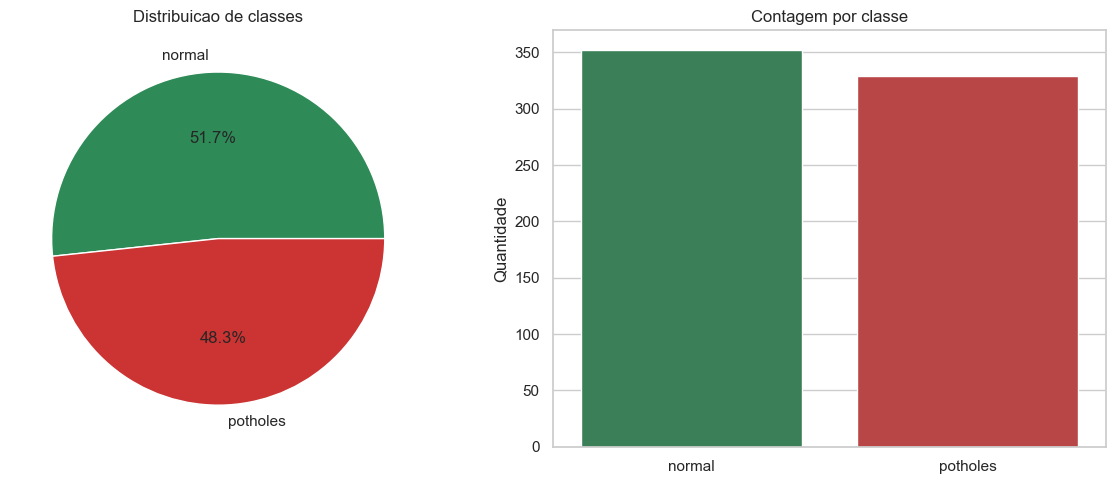

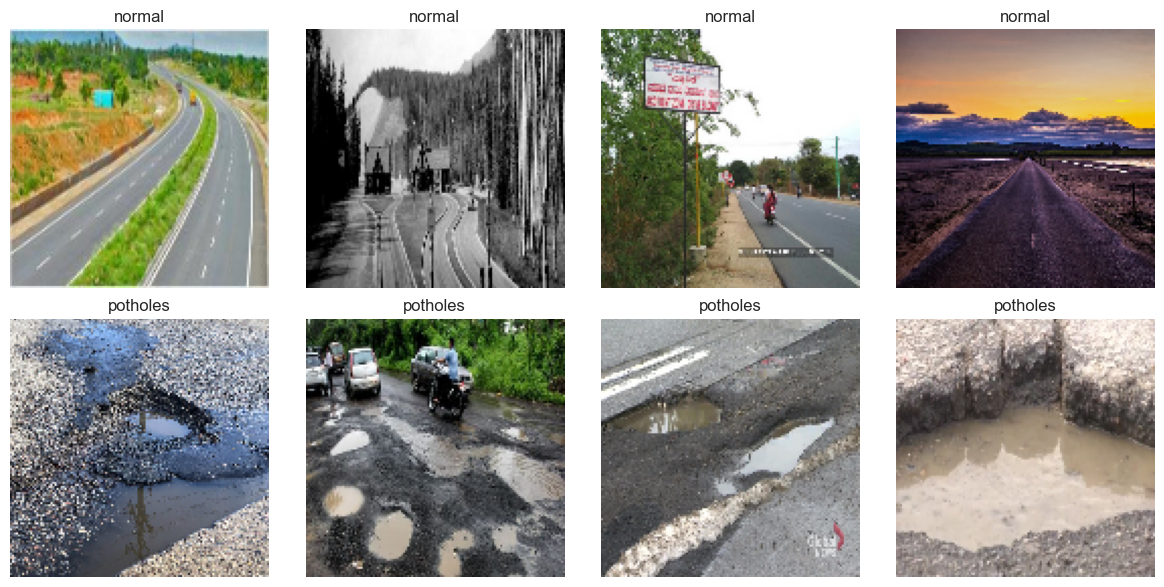

In [4]:
labels_legiveis = ["normal", "potholes"]
valores = [int(np.sum(y == MAPA_CLASSES["normal"])), int(np.sum(y == MAPA_CLASSES["potholes"]))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(valores, labels=labels_legiveis, autopct="%1.1f%%", colors=["#2e8b57", "#cc3333"])
axes[0].set_title("Distribuicao de classes")

sns.barplot(x=labels_legiveis, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])
axes[1].set_title("Contagem por classe")
axes[1].set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

# Exibe 4 amostras de cada classe para inspecao visual rapida.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
indices_normal = np.where(y == MAPA_CLASSES["normal"])[0][:4]
indices_potholes = np.where(y == MAPA_CLASSES["potholes"])[0][:4]

for i, idx in enumerate(indices_normal):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title("normal")
    axes[0, i].axis("off")

for i, idx in enumerate(indices_potholes):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title("potholes")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 5. Separação treino-validação

Separação estratificada para manter proporção de classes nos dois conjuntos.

In [5]:
X_treino, X_valid, y_treino, y_valid = separar_treino_validacao(
    X, y, PROPORCAO_VALIDACAO_PADRAO, SEMENTE_PADRAO
)

print(f"X_treino: {X_treino.shape} | y_treino: {y_treino.shape}")
print(f"X_valid: {X_valid.shape} | y_valid: {y_valid.shape}")

X_treino: (544, 128, 128, 3) | y_treino: (544,)
X_valid: (137, 128, 128, 3) | y_valid: (137,)


## 6. Treino da CNN baseline

Modelo convolucional simples para classificação binária.

In [6]:
modelo = construir_cnn_baseline(forma_entrada)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
historico = treinar_modelo(
    modelo=modelo,
    X_treino=X_treino,
    y_treino=y_treino,
    X_valid=X_valid,
    y_valid=y_valid,
    epocas=epocas,
    batch_size=batch_size,
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.5699 - loss: 0.7782 - val_accuracy: 0.8394 - val_loss: 0.6221
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.8070 - loss: 0.4780 - val_accuracy: 0.8029 - val_loss: 0.3839
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.8511 - loss: 0.3460 - val_accuracy: 0.9051 - val_loss: 0.2760
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8750 - loss: 0.2943 - val_accuracy: 0.8467 - val_loss: 0.3841
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.8952 - loss: 0.2478 - val_accuracy: 0.8759 - val_loss: 0.3011
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9062 - loss: 0.2481 - val_accuracy: 0.9051 - val_loss: 0.2376
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9301 - loss: 0.1804 - val_accuracy: 0.8978 - val_loss: 0.2749
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9283 - loss: 0.1614 - val_accuracy: 0.

## 7. Avaliação

Calculamos métricas e exibimos a matriz de confusão.

In [8]:
resultados = avaliar_modelo(modelo, X_valid, y_valid)

print(f"Acuracia de validacao: {resultados['acuracia']:.4f}")
print("\nMatriz de confusao:")
print(resultados["matriz_confusao"])

print("\nRelatorio de classificacao (resumo):")
for classe in ["normal", "potholes"]:
    metricas = resultados["relatorio_classificacao"][classe]
    print(
        f"{classe:9s} | precision={metricas['precision']:.4f} "
        f"recall={metricas['recall']:.4f} f1-score={metricas['f1-score']:.4f}"
    )

Acuracia de validacao: 0.9051

Matriz de confusao:
[[61 10]
 [ 3 63]]

Relatorio de classificacao (resumo):
normal    | precision=0.9531 recall=0.8592 f1-score=0.9037
potholes  | precision=0.8630 recall=0.9545 f1-score=0.9065


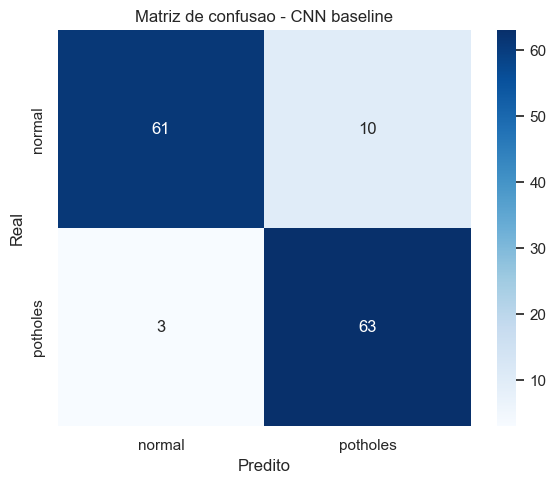

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    resultados["matriz_confusao"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "potholes"],
    yticklabels=["normal", "potholes"],
)
plt.title("Matriz de confusao - CNN baseline")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

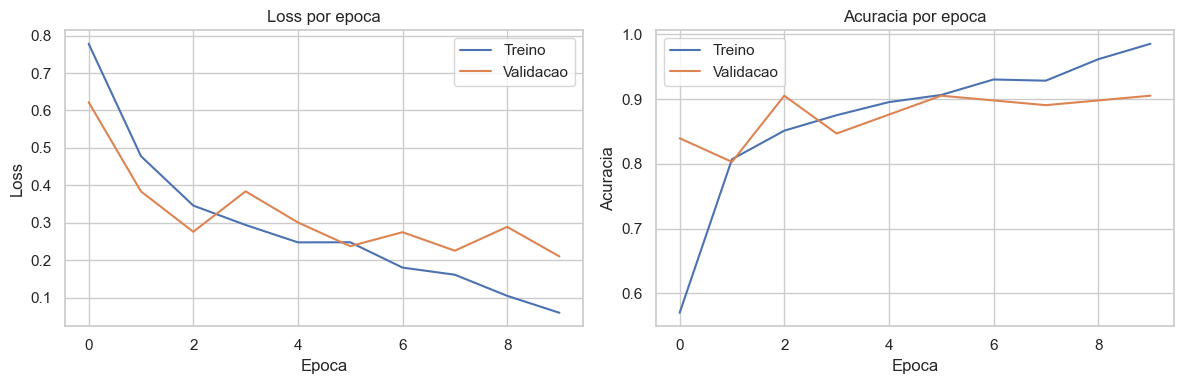

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico.history["loss"], label="Treino")
axes[0].plot(historico.history["val_loss"], label="Validacao")
axes[0].set_title("Loss por epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(historico.history["accuracy"], label="Treino")
axes[1].plot(historico.history["val_accuracy"], label="Validacao")
axes[1].set_title("Acuracia por epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Acuracia")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Conclusão

Pipeline baseline concluido com sucesso, usando codigo reutilizavel em `src` e dataset local, pronto para evolucao futura (aumento de dados, tuning e novos modelos).